# oxDNA / oxRNA in HOOMD-blue — a quick tour

This plugin implements the [oxDNA](https://dna.physics.ox.ac.uk/) coarse-grained
nucleic-acid model (**oxDNA1, oxDNA2, oxRNA2**) as native C++/CUDA forces for
HOOMD-blue. Each nucleotide is one rigid body (centre of mass + orientation) with
BACK / BASE / STACK interaction sites.

This notebook: build a duplex → see it's a real double helix → check every energy
term against the oxDNA reference → run it on the GPU.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import hoomd
import oxdna
from oxdna import io
from oxdna.model import dna2, rna2

# oxDNA reference test data (override with $OXDNA_TESTDATA)
TESTDATA = os.environ.get(
    "OXDNA_TESTDATA",
    "/groups/goloborodko/user/anton.goloborodko/src/jax-dna/jax-dna/data/test-data")

gpu = hoomd.device.GPU() if hoomd.device.GPU.is_available() else None

# --- a cohesive plot style for the whole notebook ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#ebebeb", "grid.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titlepad": 12, "axes.titleweight": "semibold",
    "font.size": 11, "axes.labelcolor": "#333333", "text.color": "#222222",
    "xtick.color": "#444444", "ytick.color": "#444444", "legend.frameon": False,
})
C = dict(strand1="#3a6ea5", strand2="#c8553d", plugin="#3a6ea5",
         ref="#e0a458", pe="#3a6ea5", hb="#c8553d")
print("HOOMD", hoomd.version.version, "| GPU available:", gpu is not None)

HOOMD 6.1.1 | GPU available: True


## 1. Build a duplex

Load a 16-base-pair oxDNA2 double helix from an oxDNA topology + configuration.

In [2]:
CASE = f"{TESTDATA}/simple-helix-oxdna2"
top = io.read_topology(f"{CASE}/generated.top")
_, box, arr = next(io.iter_conf_frames(f"{CASE}/start.conf"))
strand = np.asarray(top["strand"])
seq = "".join(top["base"][i] for i in range(top["n"]) if strand[i] == strand[0])
print(f"{top['n']} nucleotides, {top['n_strands']} strands")
print("strand-1 sequence 5'->3':", seq)

16 nucleotides, 2 strands
strand-1 sequence 5'->3': AGAAAATG


## 2. It's a real double helix

Reconstruct the BACK and BASE sites from each nucleotide's centre of mass and body axes (a1, a3), and draw the two antiparallel backbones plus the Watson-Crick base pairs.

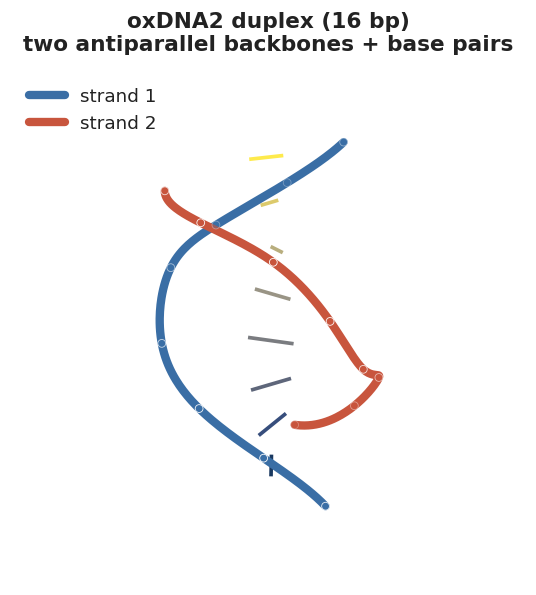

In [3]:
a1, a3 = arr[:, 3:6], arr[:, 6:9]
a2 = np.cross(a3, a1)
com = arr[:, 0:3] - arr[:, 0:3].mean(0)
back0 = com - 0.34 * a1 + 0.3408 * a2   # oxDNA2 grooved BACK site
base0 = com + 0.40 * a1                 # BASE site

# Rotate so the helix axis (largest principal component of the COMs) points up.
_, _, vt = np.linalg.svd(com, full_matrices=False)
basis = np.vstack([vt[1], vt[2], vt[0]]).T   # helix axis -> z
back, base = back0 @ basis, base0 @ basis
strand = np.asarray(top["strand"])

# Smooth each backbone into a continuous ribbon (falls back to the polyline).
try:
    from scipy.interpolate import splprep, splev
    def smooth(p, n=240):
        tck, _ = splprep(p.T, s=0, k=min(3, len(p) - 1))
        return np.array(splev(np.linspace(0, 1, n), tck)).T
except Exception:
    def smooth(p, n=240):
        return p

fig = plt.figure(figsize=(4.6, 7.2))
ax = fig.add_subplot(111, projection="3d")
strands = np.unique(strand)
for k, s in enumerate(strands):
    m = strand == s
    col = C["strand1"] if k == 0 else C["strand2"]
    curve = smooth(back[m])
    ax.plot(*curve.T, color=col, lw=5, solid_capstyle="round",
            label=f"strand {s}", zorder=2)
    ax.scatter(*back[m].T, color=col, s=22, edgecolors="white",
               linewidths=0.5, depthshade=True, zorder=3)

# base pairs: colour each rung by its position along the helix
s0 = np.where(strand == strands[0])[0]
s1 = np.where(strand == strands[1])[0]
cmap = plt.cm.cividis
for idx, i in enumerate(s0):
    d = np.linalg.norm(base[s1] - base[i], axis=1)
    if d.min() < 1.2:
        seg = np.array([base[i], base[s1[d.argmin()]]])
        ax.plot(*seg.T, color=cmap(idx / max(len(s0) - 1, 1)),
                lw=2.2, alpha=0.9, zorder=1)

ax.set_box_aspect((np.ptp(back[:, 0]), np.ptp(back[:, 1]), np.ptp(back[:, 2])))
ax.view_init(elev=10, azim=24)
ax.set_title("oxDNA2 duplex (16 bp)\ntwo antiparallel backbones + base pairs")
ax.legend(loc="upper left"); ax.set_axis_off()
plt.tight_layout(); plt.show()

## 3. Every energy term matches the oxDNA reference

Compute the eight oxDNA2 energy terms and compare, per nucleotide, against oxDNA's `split_energy.dat`.

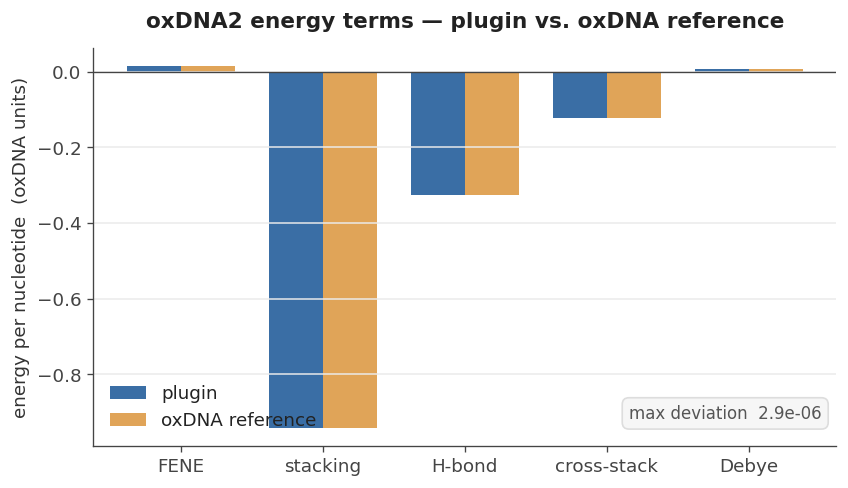

max |plugin - reference| over all terms: 2.95e-06


In [4]:
def per_term_energies(model, case, average=True, half_charged=False, salt=None):
    snap = io.build_snapshot(f"{TESTDATA}/{case}/generated.top",
                             f"{TESTDATA}/{case}/start.conf",
                             half_charged_ends=half_charged)
    n = snap.particles.N
    sim = hoomd.Simulation(device=hoomd.device.CPU())
    sim.create_state_from_snapshot(snap)
    kw = dict(average=average)
    if salt is not None:
        kw["salt"] = salt
    forces = model.forces(**kw)[0]
    sim.operations.integrator = hoomd.md.Integrator(
        dt=0.0, integrate_rotational_dof=True, forces=forces)
    sim.run(0)
    bonded, excl, hb, crst, coax, debye = forces
    got = dict(fene=bonded.fene_energy, b_exc=bonded.bonded_excvol_energy,
               stack=bonded.stacking_energy, n_exc=excl.energy, hb=hb.energy,
               cr_stack=crst.energy, cx_stack=coax.energy, debye=debye.energy)
    return {k: v / n for k, v in got.items()}

terms = ["fene", "stack", "hb", "cr_stack", "debye"]
got = per_term_energies(dna2, "simple-coax-oxdna2")   # a frame with more terms active
ref_row = np.loadtxt(f"{TESTDATA}/simple-coax-oxdna2/split_energy.dat")[0]
col = dict(fene=1, b_exc=2, stack=3, n_exc=4, hb=5, cr_stack=6, cx_stack=7, debye=8)
ref = {t: ref_row[col[t]] for t in terms}

maxdiff = max(abs(got[t] - ref[t]) for t in terms)
labels = {"fene": "FENE", "stack": "stacking", "hb": "H-bond",
          "cr_stack": "cross-stack", "debye": "Debye"}

x, w = np.arange(len(terms)), 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(x - w / 2, [got[t] for t in terms], w, label="plugin", color=C["plugin"])
ax.bar(x + w / 2, [ref[t] for t in terms], w, label="oxDNA reference",
       color=C["ref"])
ax.axhline(0, color="#444444", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([labels[t] for t in terms])
ax.set_ylabel("energy per nucleotide  (oxDNA units)")
ax.set_title("oxDNA2 energy terms — plugin vs. oxDNA reference")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower left")
ax.text(0.98, 0.06, f"max deviation  {maxdiff:.1e}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=10, color="#555555",
        bbox=dict(boxstyle="round,pad=0.4", fc="#f6f6f6", ec="#dddddd"))
plt.tight_layout(); plt.show()
print(f"max |plugin - reference| over all terms: {maxdiff:.2e}")

The plugin also does **oxRNA2** and **sequence-dependent** parametrisation (per-base-pair H-bond and stacking strengths, including the G-U wobble). Quick check:

In [5]:
for label, model, case, kw in [
    ("oxDNA2 (avg)",    dna2, "simple-coax-oxdna2",     dict()),
    ("oxDNA2 (seq-dep)", dna2, "simple-helix-oxdna2-ss", dict(average=False)),
    ("oxRNA2 (avg)",    rna2, "simple-coax-rna2",        dict(salt=1.0)),
]:
    got = per_term_energies(model, case, **kw)
    ref_row = np.loadtxt(f"{TESTDATA}/{case}/split_energy.dat")[0]
    d = max(abs(got[t] - ref_row[col[t]]) for t in ["fene", "stack", "hb", "cr_stack"])
    print(f"{label:18s} {case:24s}  max term error = {d:.1e}")

oxDNA2 (avg)       simple-coax-oxdna2        max term error = 2.9e-06
oxDNA2 (seq-dep)   simple-helix-oxdna2-ss    max term error = 2.9e-06
oxRNA2 (avg)       simple-coax-rna2          max term error = 1.5e-06


## 4. Run it on the GPU — the duplex stays bound

A short Langevin trajectory. We track the total potential energy and the hydrogen-bonding energy (which stays negative as long as the base pairs hold).

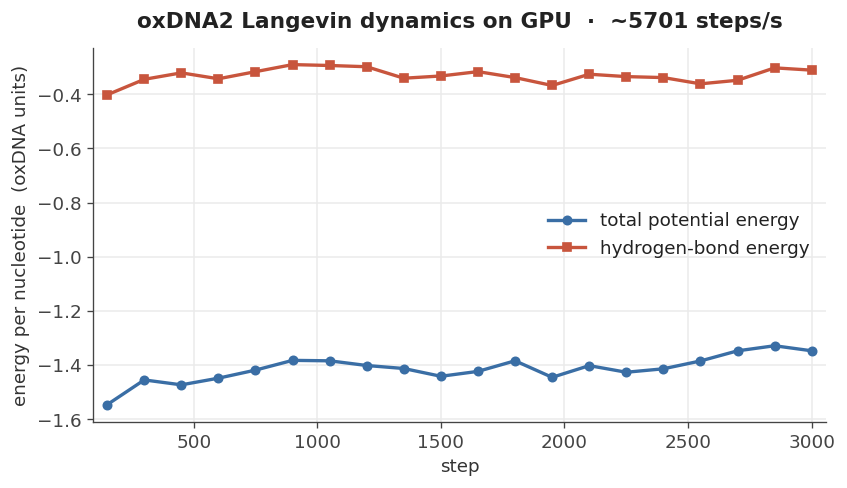

ran 3000 steps at ~5701 steps/s on GPU; final H-bond energy/nuc = -0.311 (still bound)


In [6]:
import time
snap = io.build_snapshot(f"{CASE}/generated.top", f"{CASE}/start.conf")
n = snap.particles.N
dev = gpu if gpu is not None else hoomd.device.CPU()
sim = hoomd.Simulation(device=dev, seed=3)
sim.create_state_from_snapshot(snap)
forces, nlist = dna2.forces()
kT = dna2.dna1.kT_from_temperature(296.15)
lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
sim.operations.integrator = hoomd.md.Integrator(
    dt=0.003, integrate_rotational_dof=True, forces=forces, methods=[lang])

steps, every = 3000, 150
t_hist, pe_hist, hb_hist = [], [], []
sim.run(0)
t0 = time.perf_counter()
for _ in range(steps // every):
    sim.run(every)
    t_hist.append(sim.timestep)
    pe_hist.append(sum(f.energy for f in forces) / n)
    hb_hist.append(forces[2].energy / n)
rate = steps / (time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(t_hist, pe_hist, "-o", color=C["pe"], ms=5, lw=2,
        label="total potential energy")
ax.plot(t_hist, hb_hist, "-s", color=C["hb"], ms=5, lw=2,
        label="hydrogen-bond energy")
ax.set_xlabel("step"); ax.set_ylabel("energy per nucleotide  (oxDNA units)")
ax.set_title(f"oxDNA2 Langevin dynamics on {dev.__class__.__name__}"
             f"  ·  ~{rate:.0f} steps/s")
ax.margins(x=0.02); ax.legend(loc="center right")
plt.tight_layout(); plt.show()
print(f"ran {steps} steps at ~{rate:.0f} steps/s on {dev.__class__.__name__}; "
      f"final H-bond energy/nuc = {hb_hist[-1]:.3f} (still bound)")

---
That's the whole model: **oxDNA1 / oxDNA2 / oxRNA2**, sequence-averaged and
sequence-dependent, on CPU and GPU, validated per-term against the oxDNA reference.
See `oxdna.model.dna1` / `dna2` / `rna2` and `pytest/` for the details.